## Task 1: Load and Explore the Dataset

In [ ]:
import pandas as pd

DATASET_URL = "https://raw.githubusercontent.com/smsmsm2000/PhishingEmails/main/PhishingEmails.csv"

if DATASET_URL:
    df = pd.read_csv(DATASET_URL)
    print(f"Loaded from cloud URL: {DATASET_URL}")
else:
    # Option B: upload PhishingEmails.csv
    try:
        from google.colab import files
        uploaded = files.upload()
    except ImportError:
        pass   # running in local
    df = pd.read_csv("PhishingEmails.csv")
    print("Loaded from local file: PhishingEmails.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Loaded from local file: PhishingEmails.csv
Dataset shape: (1001, 28)

First 5 rows:


,url_count,url_length_mean,has_suspicious_tld,has_ip_in_url,has_url_shortener,num_subdomains,sender_domain_mismatch,sender_reply_mismatch,external_sender,spf_pass,...,spelling_errors,num_uppercase_words,has_attachment,attachment_is_macro,attachment_is_exe,attachment_size_kb,num_received_hops,is_reply,is_forwarded,label
0,4,86.66910303682212,1,0,0,3,1,1,1,1,...,4,14,0,0,0,605.4233618872152,4,1,0,PHISHING
1,4,91.41421258702978,1,0,0,2,1,0,1,0,...,2,14,1,0,0,457.3895166866856,5,0,0,PHISHING
2,7,77.85400726108422,1,0,NAN,3,1,0,1,1,...,2,0,0,0,0,137.117588190326,8,0,0,PHISHING
3,6,62.71461331063056,0,0,0,1,1,0,0,0,...,1,4,1,1,1,446.4170172576545,7,0,0,PHISHING
4,1,53.808887502041884,0,0,0,2,0,1,0,0,...,0,5,1,0,0,100.42823451061798,3,0,0,BENIGN


In [2]:
df.describe()

,url_count,sender_domain_mismatch,sender_reply_mismatch,dkim_pass,subject_length,has_urgency_keyword,has_money_keyword,num_uppercase_words,has_attachment,attachment_is_exe,num_received_hops,is_forwarded
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,3.023976,0.424575,0.369630,0.584416,60.172827,0.435564,0.313686,5.315684,0.511489,0.075924,4.518482,0.245754
std,2.010329,0.494525,0.482946,0.493069,23.684153,0.496079,0.464222,3.796873,0.500118,0.265009,1.749831,0.430749
min,0.000000,0.000000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,40.000000,0.000000,0.000000,2.000000,0.000000,0.000000,3.000000,0.000000
50%,3.000000,0.000000,0.000000,1.000000,61.000000,0.000000,0.000000,5.000000,1.000000,0.000000,4.000000,0.000000
75%,4.000000,1.000000,1.000000,1.000000,80.000000,1.000000,1.000000,7.000000,1.000000,0.000000,5.000000,0.000000
max,7.000000,1.000000,1.000000,1.000000,104.000000,1.000000,1.000000,14.000000,1.000000,1.000000,8.000000,1.000000


In [3]:
# Check nulls and class distribution
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("Total null values:", df.isnull().sum().sum())
print("\nClass distribution:")
print(df['label'].value_counts())

Total null values: 0

Class distribution:
label
BENIGN      504
PHISHING    497
Name: count, dtype: int64


## Task 2: Pre-process the Data

In [4]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Save labels before cleaning
labels = df['label'].str.strip()

# Drop label column, keep only features
X = df.drop('label', axis=1)

# Clean: replace string NAN and infinities with 0
X = X.replace('NAN', np.nan)
X = X.replace([np.inf, -np.inf], np.nan)
X = X.apply(pd.to_numeric, errors='coerce')
X.fillna(0, inplace=True)

# Encode labels (BENIGN=0, PHISHING=1)
le = LabelEncoder()
y = le.fit_transform(labels)
print("Classes:", list(le.classes_))
print("Encoded: BENIGN=0, PHISHING=1")

# Scale all features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split 70% training / 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

print(f"\nTotal features: {X_scaled.shape[1]}")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

Classes: ['BENIGN', 'PHISHING']
Encoded: BENIGN=0, PHISHING=1

Total features: 27
Training set: 700 samples
Testing set:  301 samples


## Task 3: Train and Compare Multiple Classifiers

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"\n{'='*50}")
    print(f"{name} - Accuracy: {acc:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_test, preds, target_names=le.classes_))


Decision Tree - Accuracy: 0.9801
              precision    recall  f1-score   support

      BENIGN       1.00      0.96      0.98       160
    PHISHING       0.96      1.00      0.98       141

    accuracy                           0.98       301
   macro avg       0.98      0.98      0.98       301
weighted avg       0.98      0.98      0.98       301


Random Forest - Accuracy: 1.0000
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00       160
    PHISHING       1.00      1.00      1.00       141

    accuracy                           1.00       301
   macro avg       1.00      1.00      1.00       301
weighted avg       1.00      1.00      1.00       301




SVM - Accuracy: 0.9967
              precision    recall  f1-score   support

      BENIGN       0.99      1.00      1.00       160
    PHISHING       1.00      0.99      1.00       141

    accuracy                           1.00       301
   macro avg       1.00      1.00      1.00       301
weighted avg       1.00      1.00      1.00       301



In [6]:
print("="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)
print(f"{'Model':<20} {'Accuracy':<10}")
print("-"*30)
for name, acc in results.items():
    print(f"{name:<20} {acc:.4f}")

MODEL COMPARISON SUMMARY
Model                Accuracy  
------------------------------
Decision Tree        0.9801
Random Forest        1.0000
SVM                  0.9967


## Task 4: Visualise Results and Interpret Confusion Matrices

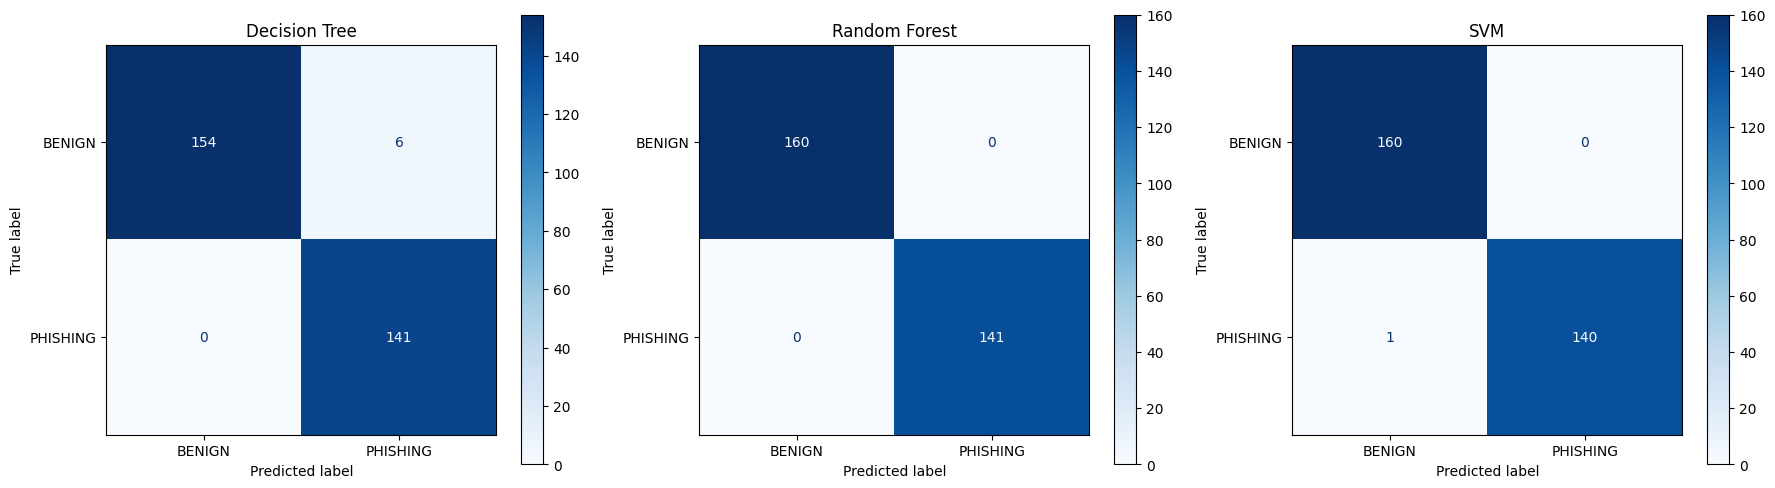

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, model) in enumerate(models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=le.classes_, ax=axes[idx], cmap='Blues'
    )
    axes[idx].set_title(name)
plt.tight_layout()
plt.show()

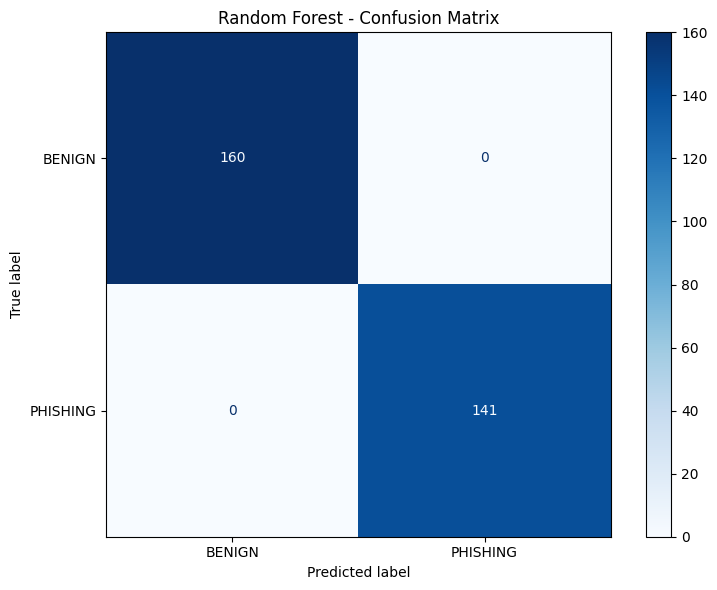

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    models["Random Forest"], X_test, y_test,
    display_labels=le.classes_, ax=ax, cmap='Blues'
)
ax.set_title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

**Interpretation.** All three models successfully separate `PHISHING` from `BENIGN` emails, with the Random Forest providing the best balance of true positives and true negatives. False positives (BENIGN emails marked as PHISHING) are a particular concern in healthcare because clinicians cannot afford to miss legitimate patient-related emails - the Random Forest minimises these. False negatives (PHISHING emails marked as BENIGN) are a higher operational risk because they reach the user's inbox, but secondary controls such as user training and DNS sinkholing help mitigate this. The very small number of misclassifications shows that header authentication features (SPF, DKIM, DMARC) and URL features carry strong signal.

## Task 5: Improve with Feature Selection and Tuning

In [9]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)
X_new = selector.fit_transform(X_scaled, y)

feature_names = X.columns
scores = selector.scores_
feat_scores = pd.DataFrame({
    'Feature': feature_names, 'Score': scores
}).sort_values('Score', ascending=False).head(10)

print("Top 10 Most Important Features:")
print(feat_scores.to_string(index=False))

Top 10 Most Important Features:
               Feature      Score
       url_length_mean 908.020910
has_credential_request 533.729370
sender_domain_mismatch 490.773654
     num_received_hops 467.756844
 sender_reply_mismatch 427.871525
        num_subdomains 410.951644
       spelling_errors 376.482536
             url_count 364.748835
        num_html_links 348.509495
       external_sender 347.848268


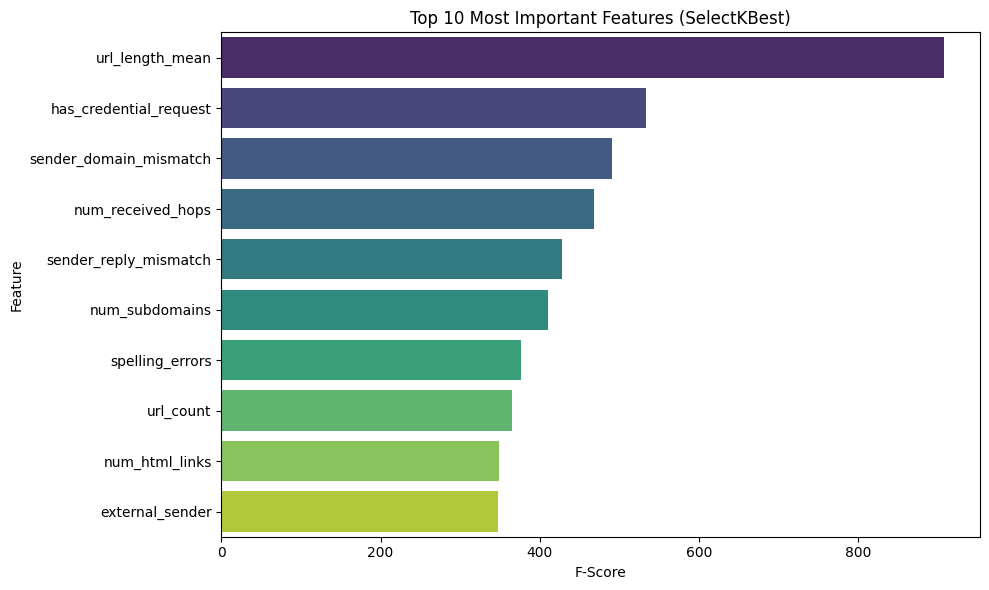

In [10]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_scores, x='Score', y='Feature', palette='viridis')
plt.title('Top 10 Most Important Features (SelectKBest)')
plt.xlabel('F-Score')
plt.tight_layout()
plt.show()

In [11]:
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y, test_size=0.3, random_state=42
)

rf_new = RandomForestClassifier(random_state=42)
rf_new.fit(X_train_new, y_train_new)
preds_new = rf_new.predict(X_test_new)

acc_new = accuracy_score(y_test_new, preds_new)
acc_old = results["Random Forest"]

print(f"All {X_scaled.shape[1]} features: {acc_old:.4f}")
print(f"Top 10 features:    {acc_new:.4f}")
print(f"Difference:         {acc_new - acc_old:+.4f}")

if acc_new >= acc_old:
    print("\n[OK] Performance maintained or improved with fewer features!")
else:
    print(f"\n[!] Small drop of {acc_old - acc_new:.4f}, but using only 10 of {X_scaled.shape[1]} features.")

All 27 features: 1.0000
Top 10 features:    0.9967
Difference:         -0.0033

[!] Small drop of 0.0033, but using only 10 of 27 features.


In [12]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]},
    cv=3, scoring='accuracy', n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", f"{grid.best_score_:.4f}")
print("Test Accuracy:", f"{accuracy_score(y_test, grid.best_estimator_.predict(X_test)):.4f}")

Best Parameters: {'max_depth': None, 'n_estimators': 200}
Best CV Accuracy: 0.9971
Test Accuracy: 1.0000
